In [2]:
pip install qiskit


In [3]:
pip install qiskit_aer


Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install qiskit[visualization]

Note: you may need to restart the kernel to use updated packages.


In [5]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np
from math import pi, cos, sin,tan,sqrt
from qiskit. circuit.library import MCMT

**#Figure 2: A Quantum circuit analogue of the physical peg**

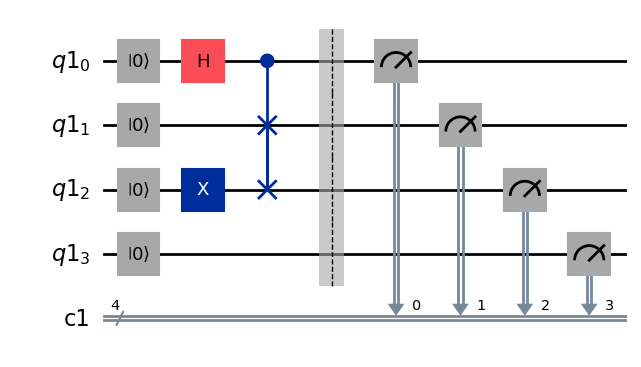

In [7]:
qreg = QuantumRegister(4, "q1")    # quantum register with 4 qubits
creg = ClassicalRegister(4, "c1")  # classical register with 2 bits
qc1 = QuantumCircuit(qreg, creg)      # quantum circuit with quantum and classical registers

qc1.reset(qreg[0])
qc1.reset(qreg[1])
qc1.reset(qreg[2])
qc1.reset(qreg[3])
qc1.h(qreg[0])    # for superposition between states
qc1.x(qreg[2])   #x work as a not gate

qc1.cswap(target_qubit1= qreg[1], target_qubit2= qreg[2], control_qubit=qreg[0])
#qc1.cx(control_qubit= q1[2], target_qubit=q1[0])
#qc1.cswap(target_qubit1= q1[3], target_qubit2= q1[2], control_qubit=q1[1])
qc1.barrier()
qc1.measure(qreg,creg)
# Display the state after entanglement
qc1.draw('mpl')

In [8]:
job = AerSimulator().run(qc1,shots=20000)
counts = job.result().get_counts(qc1)
print(counts)


{'0100': 10014, '0011': 9986}


#Plot Histogram of Measurements

In [1]:
plt.xlabel('Measurement Outcome')
plt.ylabel('Frequency')
plt.hist(counts, width=0.07 ,color='black' , edgecolor='yellow')
plt.show()

NameError: name 'plt' is not defined

#Create a Noise Model For Figer#2

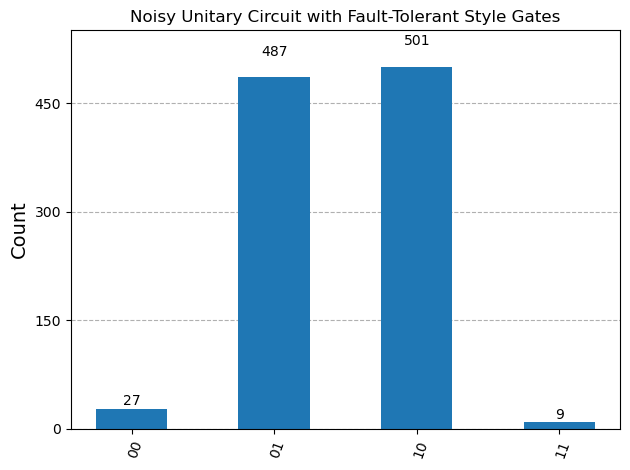

In [13]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram
from math import pi,cos,sin,tan

# Create quantum and classical registers
q1 = QuantumRegister(4,'q1')
c1 = ClassicalRegister(2,'c1')
qc1 = QuantumCircuit(q1, c1)
qc1. reset([0])
qc1.h(q1[0])
qc1.x(q1[2])

qc1.cswap(target_qubit1= q1[1], target_qubit2= q1[2], control_qubit=q1[0])
qc1.cx(control_qubit= q1[2], target_qubit=q1[0])
qc1.cswap(target_qubit1= q1[3], target_qubit2= q1[2], control_qubit=q1[0])
qc1.barrier()
# Final measurement
qc1.measure([q1[1],q1[3]], c1)

# ------------------- Noise Model -------------------
noise_model = NoiseModel()

# Depolarizing error definitions
error_1q = depolarizing_error(0.01, 1)
error_2q = depolarizing_error(0.01, 2)
error_3q = depolarizing_error(0.01, 3)

# Apply noise to appropriate gates
noise_model.add_all_qubit_quantum_error(error_1q, ['ry', 'h'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cx', 'cz'])
noise_model.add_all_qubit_quantum_error(error_3q, ['ccx','ccz'])

# Optional: Measurement noise (usually modeled separately)
# from qiskit_aer.noise.errors import ReadoutError
# noise_model.add_readout_error(ReadoutError([[0.97, 0.03], [0.03, 0.97]]), [0, 1, 2])

# ------------------- Simulation -------------------
simulator = AerSimulator(noise_model=noise_model)
transpiled_qc1 = transpile(qc1, simulator)
result = simulator.run(transpiled_qc1).result()
counts = result.get_counts()

# Plot the results
plot_histogram(counts, title="Noisy Unitary Circuit with Fault-Tolerant Style Gates"  )


## Quantum Sampling Vs Expected Exponential Distribution


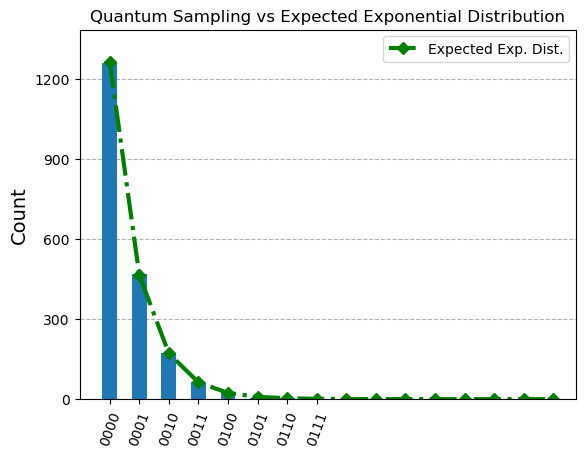

In [14]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import Initialize
from qiskit import QuantumRegister, ClassicalRegister
from math import pi,cos,sin,tan
num_qubits = 4
qr = QuantumRegister(num_qubits)
cr = ClassicalRegister(num_qubits)
qc = QuantumCircuit(qr, cr)


# Define exponential distribution parameters
lambda_param = 1.0

num_states = 2 ** num_qubits

# Create classical exponential distribution
x_vals = np.arange(num_states)
probs = np.exp(-lambda_param * x_vals)
probs /= np.sum(probs)  # Normalize

# Amplitudes for state initialization
amplitudes = np.sqrt(probs)

init_gate = Initialize(amplitudes)
qc.append(init_gate, qr)
qc.measure(qr, cr)


# Simulate
backend = AerSimulator()
transpiled_qc = transpile(qc, backend)
result = backend.run(transpiled_qc, shots=2000).result()
counts = result.get_counts()

# Plot quantum output (measured histogram)
fig, ax = plt.subplots()
plot_histogram(counts, ax=ax, bar_labels=False)

# Overlay classical exponential distribution
expected_probs = probs * 2000  # scale to ~2000 shots
expected_dict = {format(i, f'0{num_qubits}b'): expected_probs[i] for i in range(num_states)}

# Overlay plot line (expected exponential)
sorted_keys = sorted(expected_dict.keys())  # same order as histogram
expected_vals = [expected_dict[k] for k in sorted_keys]

ax.plot(sorted_keys, expected_vals, color='green', marker='D', linestyle='-.', linewidth=3, label='Expected Exp. Dist.')

ax.legend()
plt.title("Quantum Sampling vs Expected Exponential Distribution")
plt.show()


Figure 2: A Quantum circuit analogue of the physical peg for 6-Qubits

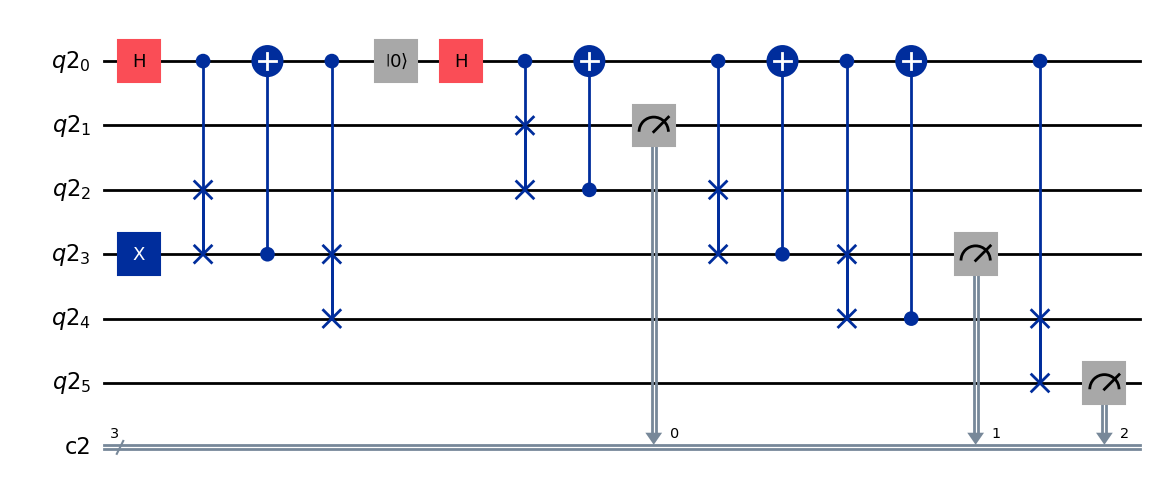

In [17]:
q2 = QuantumRegister(6, "q2")    # quantum register with 2 qubits
c2 = ClassicalRegister(3, "c2")  # classical register with 2 bits
qc2 = QuantumCircuit(q2, c2)      # quantum circuit with quantum and classical registers


qc2.h(q2[0])
qc2.x(q2[3])
qc2.cswap(target_qubit1= q2[3], target_qubit2= q2[2], control_qubit=q2[0])

qc2.cx(control_qubit= q2[3], target_qubit=q2[0])

qc2.cswap(target_qubit1= q2[3], target_qubit2= q2[4], control_qubit=q2[0])

qc2.reset(q2[0])

qc2.h(q2[0])

qc2.cswap(target_qubit1= q2[1], target_qubit2= q2[2], control_qubit=q2[0])
qc2.cx(control_qubit= q2[2], target_qubit=q2[0])
qc2.cswap(target_qubit1= q2[3], target_qubit2= q2[2], control_qubit=q2[0])
qc2.cx(control_qubit= q2[3], target_qubit=q2[0])
qc2.cswap(target_qubit1= q2[3], target_qubit2= q2[4], control_qubit=q2[0])
qc2.cx(control_qubit= q2[4], target_qubit=q2[0])
qc2.cswap(target_qubit1= q2[5], target_qubit2= q2[4], control_qubit=q2[0])



qc2.measure([q2[1],q2[3],q2[5]], c2)
# Display the state after entanglement
qc2.draw('mpl')

In [21]:
job = AerSimulator().run(qc2,shots=20000)
counts = job.result().get_counts(qc2)
print(counts)

{'001': 5082, '010': 9929, '100': 4989}


##Measurement **Outcomes**

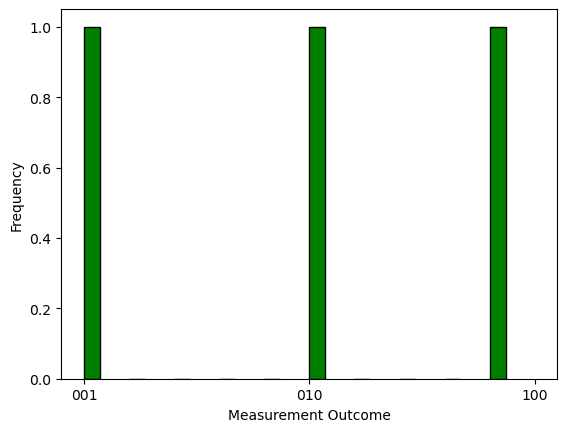

In [22]:
plt.xlabel('Measurement Outcome')
plt.ylabel('Frequency')
plt.hist(counts, width=0.07 ,color='green' , edgecolor='k')
plt.show()

#Create a Noise Model For Figer#2

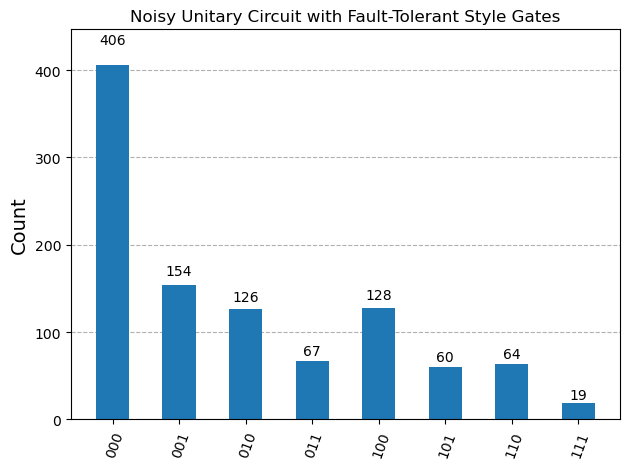

In [23]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np
from math import pi,cos,sin,tan

# Create quantum and classical registers
q1 = QuantumRegister(6,'q1')
c1 = ClassicalRegister(3,'c1')
qc1 = QuantumCircuit(q1, c1)

qc2.h(q2[0])
qc2.x(q2[3])
qc2.cswap(target_qubit1= q2[3], target_qubit2= q2[2], control_qubit=q2[0])

qc2.cx(control_qubit= q2[3], target_qubit=q2[0])

qc2.cswap(target_qubit1= q2[3], target_qubit2= q2[4], control_qubit=q2[0])

qc2.reset(q2[0])

qc2.h(q2[0])

qc2.cswap(target_qubit1= q2[1], target_qubit2= q2[2], control_qubit=q2[0])
qc2.cx(control_qubit= q2[2], target_qubit=q2[0])
qc2.cswap(target_qubit1= q2[3], target_qubit2= q2[2], control_qubit=q2[0])
qc2.cx(control_qubit= q2[3], target_qubit=q2[0])
qc2.cswap(target_qubit1= q2[3], target_qubit2= q2[4], control_qubit=q2[0])
qc2.cx(control_qubit= q2[4], target_qubit=q2[0])
qc2.cswap(target_qubit1= q2[5], target_qubit2= q2[4], control_qubit=q2[0])



qc2.measure([q2[1],q2[3],q2[5]], c2)
# Display the state after entanglement
# ------------------- Noise Model -------------------
noise_model = NoiseModel()

# Depolarizing error definitions
error_1q = depolarizing_error(0.01, 1)
error_2q = depolarizing_error(0.01, 2)
error_3q = depolarizing_error(0.01, 3)

# Apply noise to appropriate gates
noise_model.add_all_qubit_quantum_error(error_1q, ['ry', 'h'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cx', 'cz'])
noise_model.add_all_qubit_quantum_error(error_3q, ['ccx','ccz'])

# Optional: Measurement noise (usually modeled separately)
# from qiskit_aer.noise.errors import ReadoutError
# noise_model.add_readout_error(ReadoutError([[0.97, 0.03], [0.03, 0.97]]), [0, 1, 2])

# ------------------- Simulation -------------------
simulator = AerSimulator(noise_model=noise_model)
transpiled_qc2 = transpile(qc2, simulator)
result = simulator.run(transpiled_qc2).result()
counts = result.get_counts()

# Plot the results
plot_histogram(counts,  title="Noisy Unitary Circuit with Fault-Tolerant Style Gates"  )

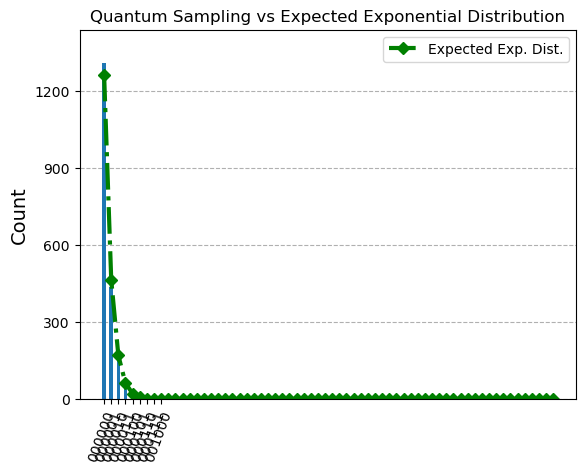

In [24]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt

# Define exponential distribution parameters
lambda_param = 1.0
num_qubits = 6
num_states = 2 ** num_qubits

# Create classical exponential distribution
x_vals = np.arange(num_states)
probs = np.exp(-lambda_param * x_vals)
probs /= np.sum(probs)  # Normalize

# Amplitudes for state initialization
amplitudes = np.sqrt(probs)

# Create circuit
from qiskit.circuit.library import Initialize
from qiskit import QuantumRegister, ClassicalRegister

qr = QuantumRegister(num_qubits)
cr = ClassicalRegister(num_qubits)
qc = QuantumCircuit(qr, cr)

init_gate = Initialize(amplitudes)
qc.append(init_gate, qr)
qc.measure(qr, cr)

# Simulate
backend = AerSimulator()
transpiled_qc = transpile(qc, backend)
result = backend.run(transpiled_qc, shots=2000).result()
counts = result.get_counts()

# Plot quantum output (measured histogram)
fig, ax = plt.subplots()
plot_histogram(counts, ax=ax, bar_labels=False)

# Overlay classical exponential distribution
expected_probs = probs * 2000  # scale to ~2000 shots
expected_dict = {format(i, f'0{num_qubits}b'): expected_probs[i] for i in range(num_states)}

# Overlay plot line (expected exponential)
sorted_keys = sorted(expected_dict.keys())  # same order as histogram
expected_vals = [expected_dict[k] for k in sorted_keys]

ax.plot(sorted_keys, expected_vals, color='green', marker='D', linestyle='-.', linewidth=3, label='Expected Exp. Dist.')

ax.legend()
plt.title("Quantum Sampling vs Expected Exponential Distribution")
plt.show()
